In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns 

In [66]:
df = pd.read_csv('./bmw_global_sales_2018_2025.csv')
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [67]:
X = df.drop(columns=['Model','Month','Year','Region'],axis=1)
y = df['Model']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

In [69]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

In [70]:
parameter_grid = {
    'knn__n_neighbors':range(1,21),
    'knn__weights':['uniform','distance'],
    'knn__metric':['euclidean','manhattan']
}

grid = GridSearchCV(
    pipeline,
    parameter_grid,
    cv=5,
    scoring='accuracy'
)

In [71]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': range(1, 21),
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [72]:
best_model = grid.best_estimator_
print(grid.best_params_)

{'knn__metric': 'manhattan', 'knn__n_neighbors': 19, 'knn__weights': 'distance'}


In [73]:
y_pred = best_model.predict(X_test)

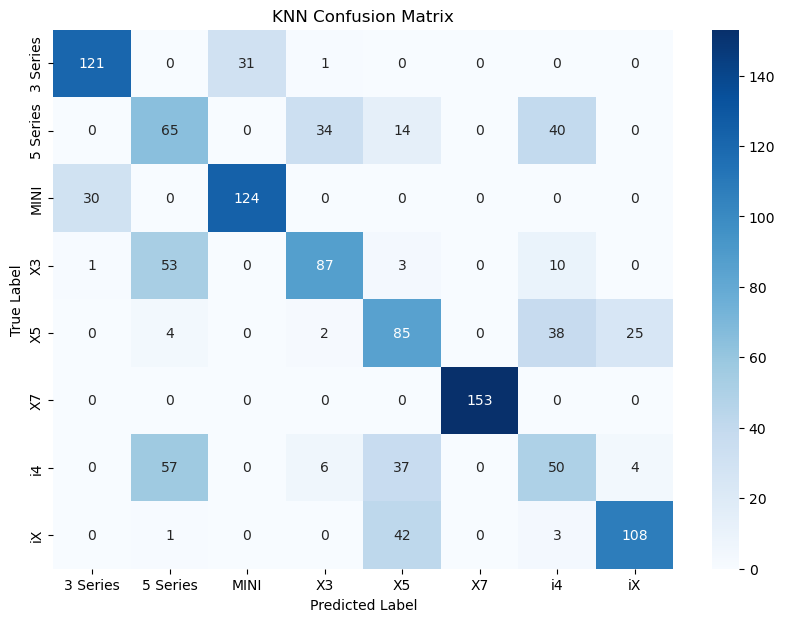

In [74]:
cm = confusion_matrix(y_test, y_pred)
labels = best_model.classes_

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix")
plt.show()

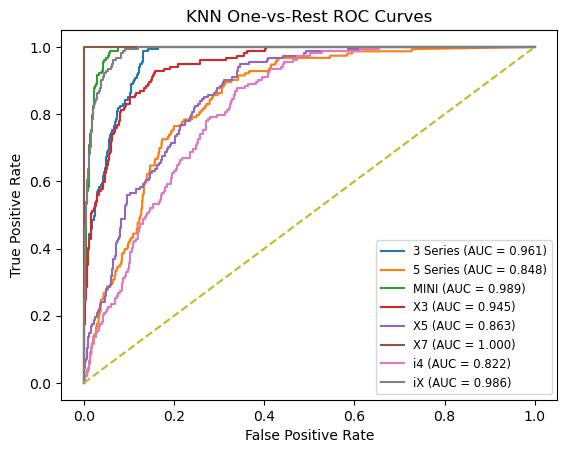

In [75]:
# classes in the same order as model.predict_proba output
classes = best_model.classes_

# Convert y_test into a one-hot/binarized matrix
y_test_bin = label_binarize(y_test, classes=classes)

# Probabilities for each class: shape = (n_samples, n_classes)
y_proba = best_model.predict_proba(X_test)

plt.figure()

for i, clas in enumerate(classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clas} (AUC = {roc_auc:.3f})")

# diagonal baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN One-vs-Rest ROC Curves")
plt.legend(loc="lower right", fontsize="small")
plt.show()